In [1]:
# Mudança na API do Keras, o Keras Preprocessing está OBSOLETO!
# tensorflow.keras.preprocessing.classeQuePrecisar não deve ser usado
# https://github.com/keras-team/keras-preprocessing?tab=readme-ov-file

# Deve ser usado as Camadas de Pré-processamento do Keras 3 para chamar as funções de transformação!
# tensorflow.keras.layers.classeQuePrecisar
# https://keras.io/api/layers/preprocessing_layers/#image-augmentation-layers

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import os


2024-12-04 11:10:10.334430: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

In [3]:
# Keras usa a biblioteca PIL
# import PIL
# print(PIL.__version__)
from PIL import Image
from PIL.Image import Image as Img

try:
    pil_image: Img = Image.open(mask_path)
    print("PIL Image opened successfully")
    print("Original size:", pil_image.size)
except Exception as e:
    print(f"Error opening image with PIL: {e}")

PIL Image opened successfully
Original size: (1920, 1080)


In [4]:
# Teste com Tensorflow
try:
    image_original: Img = tf.keras.utils.load_img(mask_path)
    print("TensorFlow load_img successful")
    print("Original size:", image_original.size)
except Exception as e:
    print(f"Error with tf.keras.utils.load_img: {e}")

TensorFlow load_img successful
Original size: (1920, 1080)


Tamanho original: (1920, 1080)
Tamanho redimensionado: (910, 512)


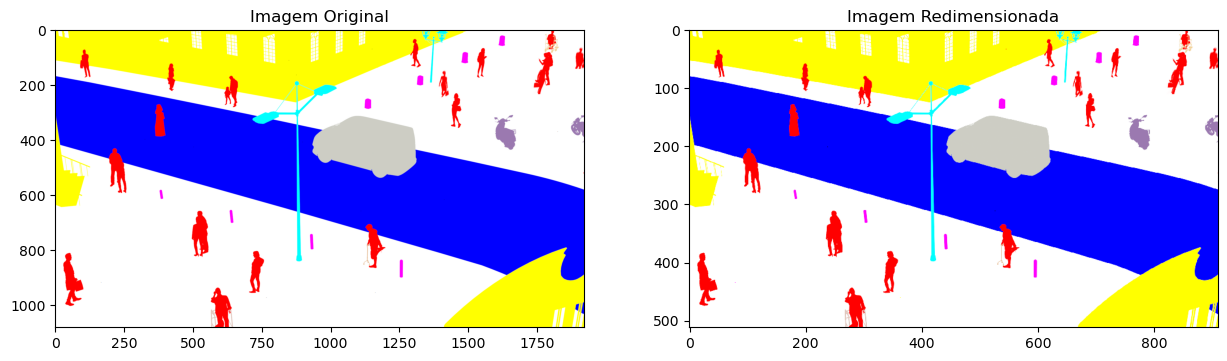

In [5]:
# Documentação sobre como carregar imagens
# https://keras.io/api/data_loading/image/

# Por hora iniciarei os testes de forma singular usando "load_img, img_to_array, save_img, array_to_img"

# Carregamento de imagem
# Imagem original (1920x1080)
image_original: Img = tf.keras.utils.load_img(mask_path)
print("Tamanho original:", image_original.size)

# Redimensionamento para 910x512 na própria função de carregamento
image_resized: Img = tf.keras.utils.load_img(
    mask_path, 
    target_size=(512, 910)  # (altura, largura)
)
print("Tamanho redimensionado:", image_resized.size)

# Ambos os retornos do load_img são instâncias PIL image

# Visualização
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Imagem Original')
plt.imshow(image_original)
plt.subplot(1,2,2)
plt.title('Imagem Redimensionada')
plt.imshow(image_resized)
plt.show()


Tamanho redimensionado: [254, 254, 3]


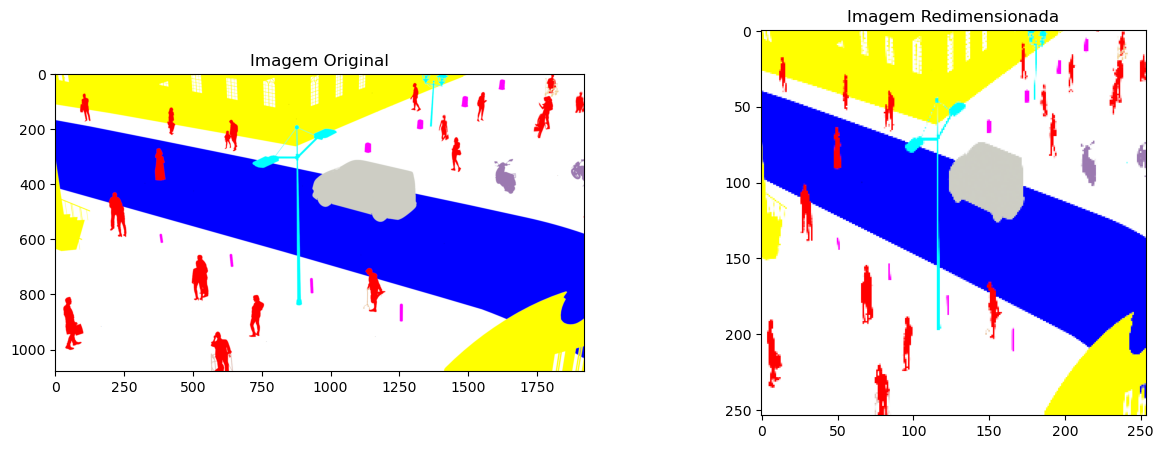

In [6]:
# Testes das classes de Pre Processamento do Keras 3

# https://keras.io/api/layers/preprocessing_layers/image_preprocessing/resizing/
# tf.keras.layers.Resizing(
#     height,
#     width,
#     interpolation="bilinear",
#     crop_to_aspect_ratio=False,
#     pad_to_aspect_ratio=False,
#     fill_mode="constant",
#     fill_value=0.0,
#     data_format=None,
#     # **kwargs # keyword arguments like name, dtype...
# )

resizing_layer = tf.keras.layers.Resizing(height=254, width=254, interpolation="bilinear")
image_resized: Img = resizing_layer(image_original)
print("Tamanho redimensionado:", image_resized.get_shape().as_list())

# Visualização
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Imagem Original')
plt.imshow(image_original)
plt.subplot(1,2,2)
plt.title('Imagem Redimensionada')
plt.imshow(image_resized)
plt.show()

Faixa de valores dos pixels da imagem original: tf.Tensor(0.0, shape=(), dtype=float32) a tf.Tensor(255.0, shape=(), dtype=float32)
Faixa de valores dos pixels da imagem rescalada: tf.Tensor(0.0, shape=(), dtype=float32) a tf.Tensor(1.0, shape=(), dtype=float32)


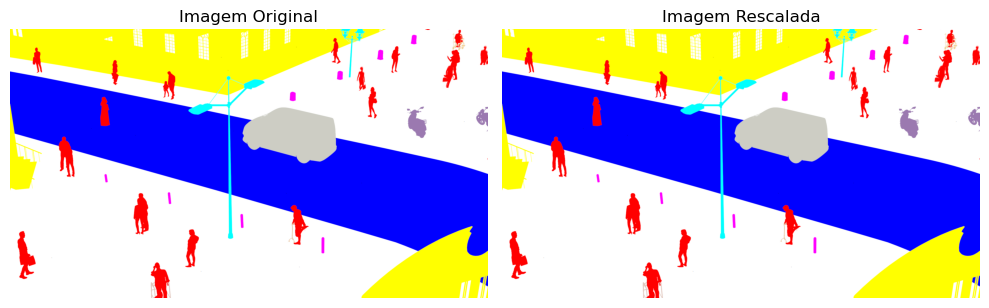

Tamanho da imagem rescalada: [1080, 1920, 3]


In [7]:
# https://keras.io/api/layers/preprocessing_layers/image_preprocessing/rescaling/
# keras.layers.Rescaling(scale, offset=0.0, **kwargs)
# To rescale an input in the [0, 255] range to be in the [0, 1] range, you would pass scale=1./255.
from numpy import ndarray

numpy_image: ndarray = tf.keras.utils.img_to_array(image_original)
rescaling_layer = tf.keras.layers.Rescaling(scale=1./255, offset=0)
rescaled_image = rescaling_layer(numpy_image)

# Valores mínimos e máximos
print("Faixa de valores dos pixels da imagem original:", tf.reduce_min(numpy_image), "a", tf.reduce_max(numpy_image))
print("Faixa de valores dos pixels da imagem rescalada:", tf.reduce_min(rescaled_image), "a", tf.reduce_max(rescaled_image))

# Visualizar as imagens
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(numpy_image.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rescaled_image)
plt.title('Imagem Rescalada')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Tamanho da imagem rescalada:", rescaled_image.get_shape().as_list())

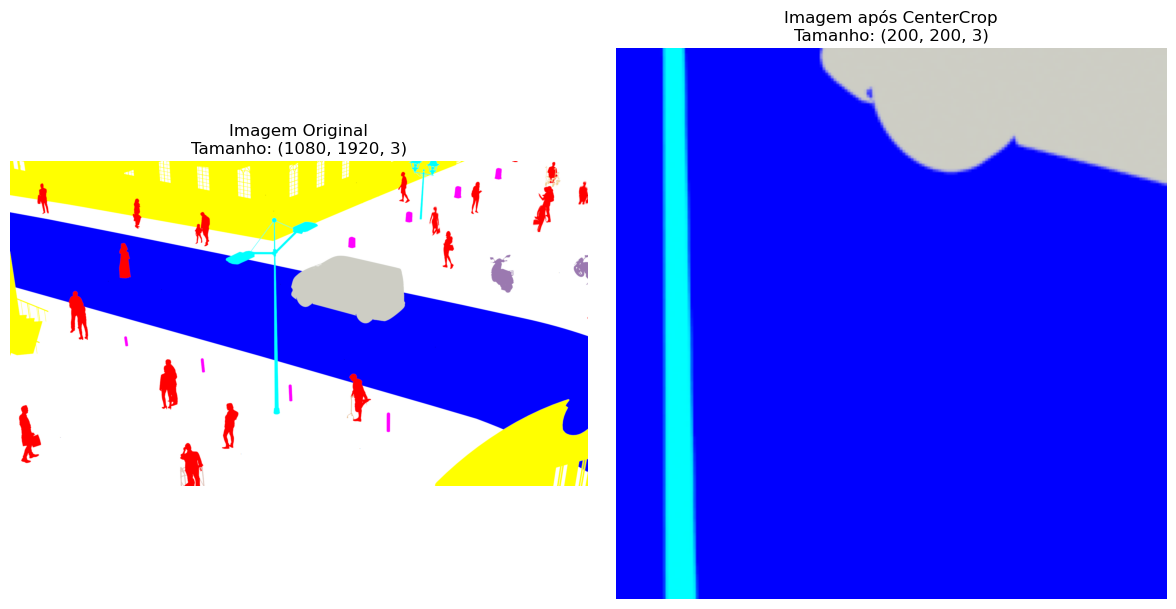

Dimensões da imagem original: (1080, 1920, 3)
Dimensões após o corte central: (200, 200, 3)


In [8]:
# https://keras.io/api/layers/preprocessing_layers/image_preprocessing/center_crop/
# keras.layers.CenterCrop(height, width, data_format=None, **kwargs)

import tensorflow as tf
import matplotlib.pyplot as plt

# Carrega a imagem
# mask_path = 'caminho/para/sua/imagem.jpg'
# image_original = tf.keras.utils.load_img(image_path)
image_tensor: ndarray = tf.keras.utils.img_to_array(image_original)

# Criar e aplicar a camada CenterCrop
center_crop_layer = tf.keras.layers.CenterCrop(height=200, width=200)
cropped_image = center_crop_layer(image_tensor)

# Visualizar as imagens original e cortada
plt.figure(figsize=(12, 6))

# Imagem original
plt.subplot(1, 2, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title(f'Imagem Original\nTamanho: {image_tensor.shape}')
plt.axis('off')

# Imagem cortada
plt.subplot(1, 2, 2)
plt.imshow(cropped_image.numpy().astype('uint8'))
plt.title(f'Imagem após CenterCrop\nTamanho: {cropped_image.shape}')
plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar as dimensões
print("Dimensões da imagem original:", image_tensor.shape)
print("Dimensões após o corte central:", cropped_image.shape)